<a href="https://colab.research.google.com/github/puteriazli/data-analysis-for-air-quality-monitoring/blob/main/data_analysis_for_air_quality_monitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Monitoring Kualitas Udara di Kota Ancona Eropa

# Intoduction

**Puteri Amelia Azli**

*12 Juni 2024*

Dibuat untuk memenuhi ujian sertifikasi data science di Bisa AI Academy

**Tentang dataset**

Ancaman kesehatan lingkungan utama di Wilayah Eropa adalah polusi udara, yang berdampak signifikan terhadap kesehatan dan kesejahteraan sehari-hari warganya. Untuk memahami dampak dan dinamika kualitas udara secara efektif, penyelidikan terperinci terhadap berbagai indeks lingkungan, cuaca, dan tutupan lahan adalah tepat. Untuk tujuan ini, kumpulan data spatio-temporal tiga kota di Eropa disesuaikan untuk pemantauan polusi udara di tingkat regional. Durasinya kira-kira dari 2020 hingga 2023, dengan resolusi temporal per jam dan resolusi spasial 0,005 derajat.

**Informasi rinci tentang setiap kolom dalam dataset berikut:**

1. Date - Tanggal dan waktu pengamatan (YYYY-MM-DD HH:MM:SS).
2. NO2 - Konsentrasi nitrogen dioksida di atmosfer (μg/m3).
3. O3 - Konsentrasi ozon di atmosfer. Sejumlah penelitian tentang interaksi nitrogen dioksida dengan polutan udara lainnya, terutama ozon, menunjukkan bahwa efeknya disebabkan oleh ozon saja, bersifat aditif atau sinergis (μg / m3).
4. PM10 - Konsentrasi aerosol atmosfer dengan diameter partikel maksimum 10 mikrometer (μg/m3).
5. PM2.5 - Konsentrasi aerosol atmosfer dengan diameter partikel maksimum 2,5 mikrometer (μg/m3).
6. Latitude - Koordinat geografis (derajat).
7. Longitude - Koordinat geografis (derajat).
8. station_name - Nama stasiun pemantauan kualitas udara.
9. Wind-Speed (U)- Komponen angin U sejajar dengan sumbu x (yaitu bujur). Angin U positif datang dari barat, dan angin U negatif datang dari timur (m / s).
10. Wind-Speed (V) - Komponen angin V sejajar dengan sumbu y (yaitu lintang). Angin V positif berasal dari selatan, dan angin V negatif berasal dari utara (m / s).
10. Dewpoint Temp - Titik suhu di mana udara tidak dapat menahan air lagi (uap air).
12. Temp - Suhu udara.
13. Vegitation (High) - Penutup tanaman tingkat tinggi.
14. Vegitation (Low) - Penutup tanaman tingkat rendah.
15. Soil Temp - Suhu tanah rata-rata.
16. Total Percipitation - Fluks setara air (hujan atau salju) mencapai permukaan tanah (mm).
17. Relative Humidity - Jumlah aktual uap air di udara dibandingkan dengan jumlah total uap yang dapat ada di udara pada suhu saat ini (%).
18. code - Kode stasiun pemantauan kualitas udara.
19. id - ID stasiun pemantauan kualitas udara.

Dataset dapat diunduh pada link berikut: https://www.kaggle.com/datasets/yekenot/air-quality-monitoring-in-european-cities

# Persiapan

**Mengimpor Library yang Diperlukan**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

**Mengunduh Dataset dari Kaggle**

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"puteriameliaazli","key":"8b1708e278738bd4d92e768870362e99"}'}

In [ ]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d yekenot/air-quality-monitoring-in-european-cities

Dataset URL: https://www.kaggle.com/datasets/yekenot/air-quality-monitoring-in-european-cities
License(s): Attribution 4.0 International (CC BY 4.0)
 57% 107M/188M [00:00<00:00, 1.12GB/s]
100% 188M/188M [00:00<00:00, 425MB/s] 


In [ ]:
!unzip air-quality-monitoring-in-european-cities.zip

Archive:  air-quality-monitoring-in-european-cities.zip
  inflating: ancona_data.csv         
  inflating: athens_data.csv         
  inflating: zaragoza_data.csv       


# Memuat dan Memahami Data

**Memuat Data**

In [ ]:
data = pd.read_csv('ancona_data.csv')

**Menampilkan Informasi Dasar**

In [ ]:
data.head()

,Date,NO2,O3,PM10,PM2.5,Latitude,Longitude,station_name,Wind-Speed (U),Wind-Speed (V),Dewpoint Temp,Soil Temp,Total Percipitation,Vegitation (High),Vegitation (Low),Temp,Relative Humidity,code,id
0,2021-09-01 01:00:00,7.000000,53.000000,15.000000,4.000000,43.612386,13.510830,Ancona Citadella,-0.528286,-0.987673,63.563788,66.476667,0.0,3.184390,2.847654,66.075624,85.422435,IT1827A,26
1,2021-09-01 01:00:00,8.000000,NaN,9.000000,NaN,43.527982,13.246672,Jesi,-0.529657,-0.987282,64.894507,67.803820,0.0,3.179204,2.851910,67.392994,85.502078,IT0460A,23
2,2021-09-01 01:00:00,9.035176,49.232338,10.681684,7.700312,43.450000,13.250000,Ancona CAMS Station 11,-0.529798,-0.987225,65.123477,68.032686,0.0,3.176792,2.852830,67.622493,85.500013,ANCCAMS11,39
3,2021-09-01 01:00:00,10.292098,51.336113,10.310384,6.732396,43.550000,13.450000,Ancona CAMS Station 8,-0.528619,-0.987565,63.943511,66.855648,0.0,3.181947,2.849007,66.453195,85.435906,ANCCAMS08,36
4,2021-09-01 01:00:00,8.348963,39.351303,10.273862,7.066792,43.550000,13.150000,Ancona CAMS Station 5,-0.530069,-0.987179,65.208544,68.116622,0.0,3.179280,2.852743,67.701531,85.534001,ANCCAMS05,33


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417626 entries, 0 to 417625
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Date                 417626 non-null  object 
 1   NO2                  409848 non-null  float64
 2   O3                   392823 non-null  float64
 3   PM10                 389767 non-null  float64
 4   PM2.5                372508 non-null  float64
 5   Latitude             417626 non-null  float64
 6   Longitude            417626 non-null  float64
 7   station_name         417626 non-null  object 
 8   Wind-Speed (U)       417626 non-null  float64
 9   Wind-Speed (V)       417626 non-null  float64
 10  Dewpoint Temp        417626 non-null  float64
 11  Soil Temp            417626 non-null  float64
 12  Total Percipitation  417626 non-null  float64
 13  Vegitation (High)    417626 non-null  float64
 14  Vegitation (Low)     417626 non-null  float64
 15  Temp             

In [ ]:
data.describe()

,NO2,O3,PM10,PM2.5,Latitude,Longitude,Wind-Speed (U),Wind-Speed (V),Dewpoint Temp,Soil Temp,Total Percipitation,Vegitation (High),Vegitation (Low),Temp,Relative Humidity,id
count,409848.000000,392823.000000,389767.000000,372508.000000,417626.000000,417626.000000,417626.000000,417626.000000,417626.000000,417626.000000,4.176260e+05,417626.000000,417626.000000,417626.000000,417626.000000,417626.000000
mean,12.827087,56.985822,18.901080,13.029915,43.567772,13.363402,-0.112081,-0.203619,50.186664,55.321276,1.644118e-03,3.059505,2.777506,55.232497,75.301643,34.636364
std,9.463539,25.881841,10.480908,7.852031,0.074816,0.127325,0.889874,0.956847,17.823638,18.173232,4.932701e-03,0.248034,0.147349,18.209059,18.553947,13.452104
min,0.000000,0.000000,0.000000,0.000000,43.450000,13.150000,-3.877032,-3.671453,8.371775,12.047776,-6.940000e-18,2.718726,2.573985,10.109338,12.943158,22.000000
25%,6.426122,38.156440,11.937048,7.866542,43.527982,13.250000,-0.735605,-0.996508,48.866307,52.033239,2.305655e-07,2.810968,2.628907,52.015683,62.288855,27.000000
50%,10.320171,56.561120,16.547325,11.193825,43.574761,13.361060,-0.368986,-0.360379,56.987120,59.744633,1.271375e-05,3.057545,2.776209,60.127705,79.907559,32.500000
75%,16.195905,74.819915,23.530932,16.167352,43.637500,13.450000,0.456399,0.529858,62.168484,66.947640,6.119069e-04,3.271532,2.902817,66.983502,90.889160,38.000000
max,285.000000,162.000000,249.000000,200.000000,43.650000,13.550000,3.617407,4.307326,72.999793,90.073126,7.496383e-02,3.470822,3.022056,88.419472,99.996023,90.000000


# Pre-processing Data

**Mengatasi Nilai yang Hilang (Missing Value)**

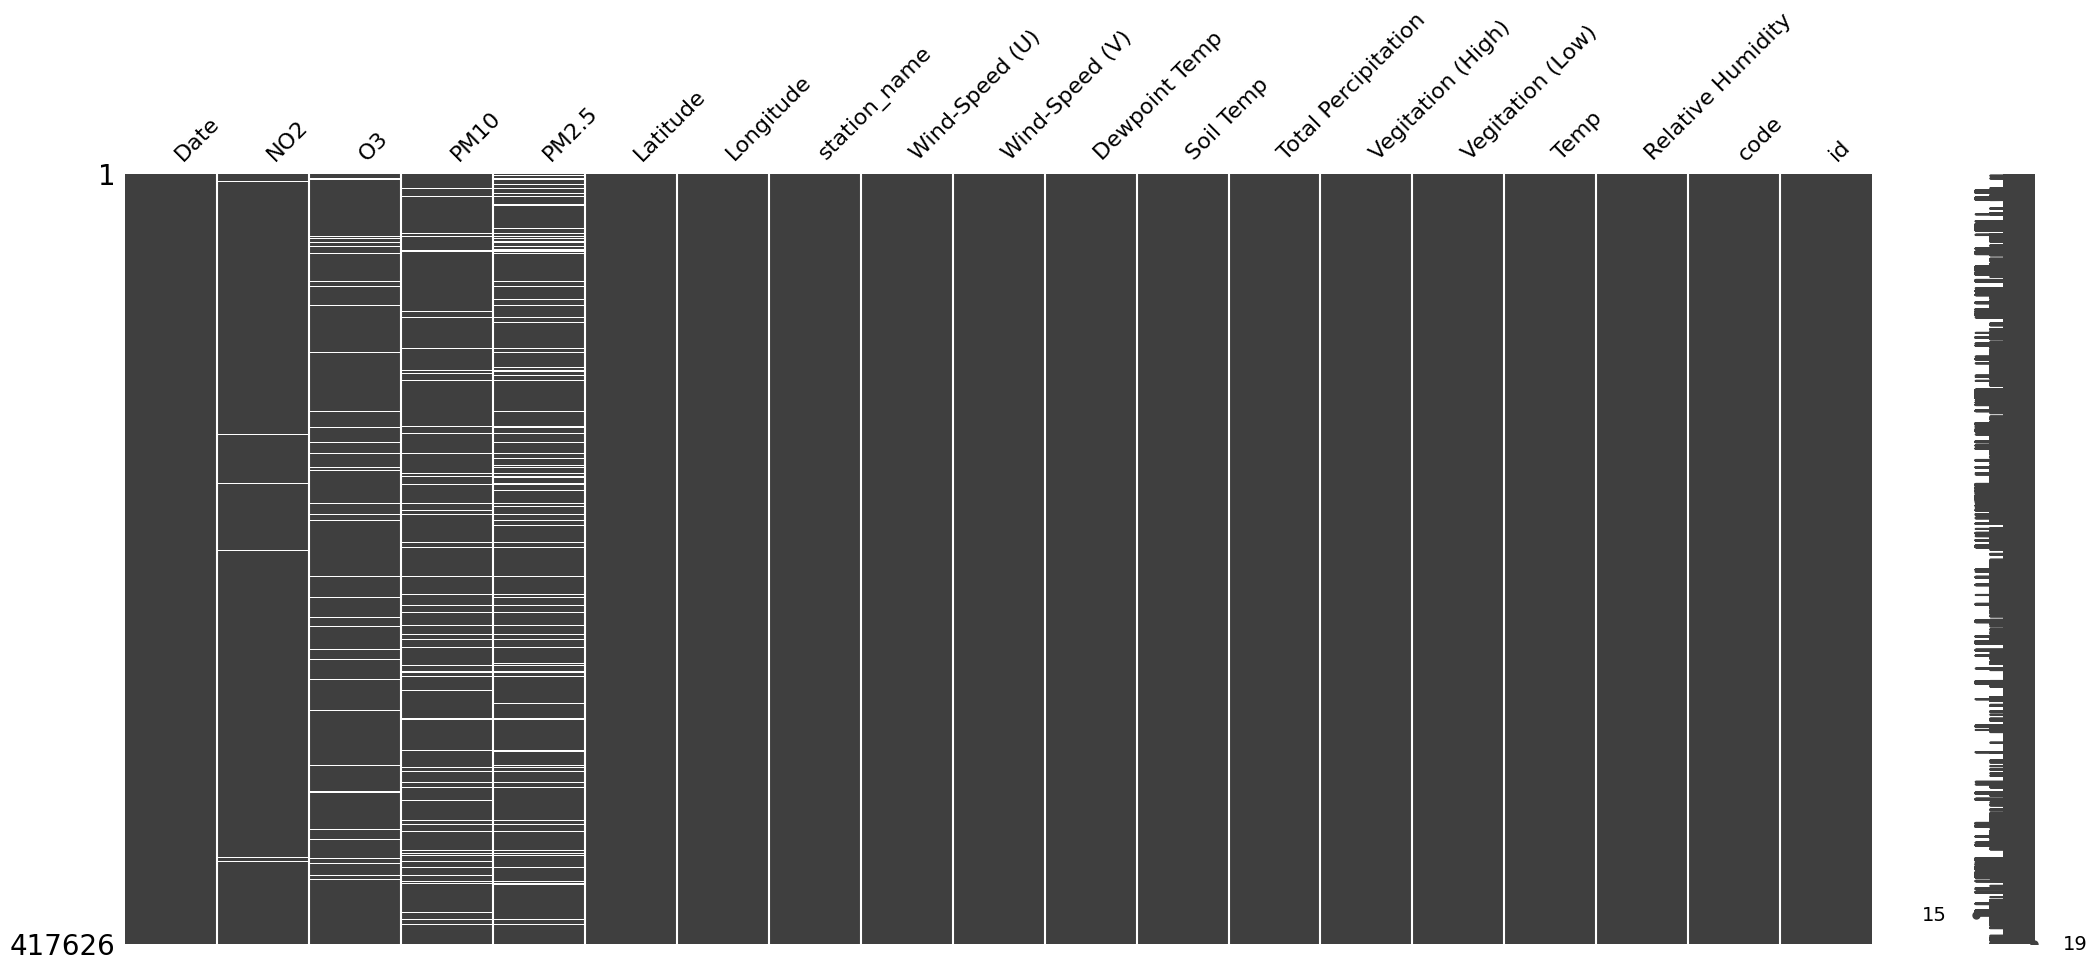

In [ ]:
msno.matrix(data)
plt.show()

In [ ]:
data = data.dropna()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 356075 entries, 0 to 417624
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Date                 356075 non-null  object 
 1   NO2                  356075 non-null  float64
 2   O3                   356075 non-null  float64
 3   PM10                 356075 non-null  float64
 4   PM2.5                356075 non-null  float64
 5   Latitude             356075 non-null  float64
 6   Longitude            356075 non-null  float64
 7   station_name         356075 non-null  object 
 8   Wind-Speed (U)       356075 non-null  float64
 9   Wind-Speed (V)       356075 non-null  float64
 10  Dewpoint Temp        356075 non-null  float64
 11  Soil Temp            356075 non-null  float64
 12  Total Percipitation  356075 non-null  float64
 13  Vegitation (High)    356075 non-null  float64
 14  Vegitation (Low)     356075 non-null  float64
 15  Temp                 3

**Mengonversi Tipe Data**

In [ ]:
data['Date'] = pd.to_datetime(data['Date'])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 356075 entries, 0 to 417624
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Date                 356075 non-null  datetime64[ns]
 1   NO2                  356075 non-null  float64       
 2   O3                   356075 non-null  float64       
 3   PM10                 356075 non-null  float64       
 4   PM2.5                356075 non-null  float64       
 5   Latitude             356075 non-null  float64       
 6   Longitude            356075 non-null  float64       
 7   station_name         356075 non-null  object        
 8   Wind-Speed (U)       356075 non-null  float64       
 9   Wind-Speed (V)       356075 non-null  float64       
 10  Dewpoint Temp        356075 non-null  float64       
 11  Soil Temp            356075 non-null  float64       
 12  Total Percipitation  356075 non-null  float64       
 13  Vegitation (High)  

In [ ]:
data.head()

,Date,NO2,O3,PM10,PM2.5,Latitude,Longitude,station_name,Wind-Speed (U),Wind-Speed (V),Dewpoint Temp,Soil Temp,Total Percipitation,Vegitation (High),Vegitation (Low),Temp,Relative Humidity,code,id
0,2021-09-01 01:00:00,7.000000,53.000000,15.000000,4.000000,43.612386,13.51083,Ancona Citadella,-0.528286,-0.987673,63.563788,66.476667,0.0,3.184390,2.847654,66.075624,85.422435,IT1827A,26
2,2021-09-01 01:00:00,9.035176,49.232338,10.681684,7.700312,43.450000,13.25000,Ancona CAMS Station 11,-0.529798,-0.987225,65.123477,68.032686,0.0,3.176792,2.852830,67.622493,85.500013,ANCCAMS11,39
3,2021-09-01 01:00:00,10.292098,51.336113,10.310384,6.732396,43.550000,13.45000,Ancona CAMS Station 8,-0.528619,-0.987565,63.943511,66.855648,0.0,3.181947,2.849007,66.453195,85.435906,ANCCAMS08,36
4,2021-09-01 01:00:00,8.348963,39.351303,10.273862,7.066792,43.550000,13.15000,Ancona CAMS Station 5,-0.530069,-0.987179,65.208544,68.116622,0.0,3.179280,2.852743,67.701531,85.534001,ANCCAMS05,33
5,2021-09-01 01:00:00,9.253618,57.373196,9.802318,6.018585,43.550000,13.55000,Ancona CAMS Station 9,-0.528127,-0.987702,63.479773,66.393293,0.0,3.183379,2.847571,65.994794,85.404336,ANCCAMS09,37


**Transformasi Data**

In [ ]:
scaler = StandardScaler()
data[['PM2.5', 'PM10', 'O3', 'NO2']] = scaler.fit_transform(data[['PM2.5', 'PM10', 'O3','NO2']])

**Reduksi Dimensi**

In [ ]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data[['PM2.5', 'PM10', 'O3', 'NO2']])

In [ ]:
data['PCA1'] = data_pca[:, 0]
data['PCA2'] = data_pca[:, 1]

# Exploratory Data Analysis (EDA)

**Deskriptif Statistik**

In [ ]:
print(data.describe())

                                Date           NO2            O3  \
count                         356075  3.560750e+05  3.560750e+05   
mean   2022-10-05 19:50:14.193077760 -9.195200e-17 -2.135968e-16   
min              2021-09-01 01:00:00 -1.378911e+00 -2.279773e+00   
25%              2022-03-22 14:00:00 -6.767668e-01 -7.161758e-01   
50%              2022-10-09 16:00:00 -2.426290e-01 -2.593906e-02   
75%              2023-04-20 01:00:00  3.694985e-01  6.794662e-01   
max              2023-10-31 23:00:00  3.184086e+01  4.101181e+00   
std                              NaN  1.000001e+00  1.000001e+00   

               PM10         PM2.5       Latitude      Longitude  \
count  3.560750e+05  3.560750e+05  356075.000000  356075.000000   
mean   2.477596e-16 -2.681933e-16      43.562854      13.365402   
min   -1.847093e+00 -1.693206e+00      43.450000      13.150000   
25%   -6.705222e-01 -6.635799e-01      43.450000      13.250000   
50%   -2.266573e-01 -2.315942e-01      43.550000    

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 356075 entries, 0 to 417624
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Date                 356075 non-null  datetime64[ns]
 1   NO2                  356075 non-null  float64       
 2   O3                   356075 non-null  float64       
 3   PM10                 356075 non-null  float64       
 4   PM2.5                356075 non-null  float64       
 5   Latitude             356075 non-null  float64       
 6   Longitude            356075 non-null  float64       
 7   station_name         356075 non-null  object        
 8   Wind-Speed (U)       356075 non-null  float64       
 9   Wind-Speed (V)       356075 non-null  float64       
 10  Dewpoint Temp        356075 non-null  float64       
 11  Soil Temp            356075 non-null  float64       
 12  Total Percipitation  356075 non-null  float64       
 13  Vegitation (High)  

**Korelasi Antar Variabel**

In [ ]:
correlation_matrix = data[['NO2', 'O3', 'PM10', 'PM2.5', 'Latitude', 'Longitude', 'Wind-Speed (U)', 'Wind-Speed (V)', 'Dewpoint Temp', 'Soil Temp', 'Total Percipitation', 'Vegitation (High)', 'Vegitation (Low)', 'Temp', 'Relative Humidity', 'id']].corr()

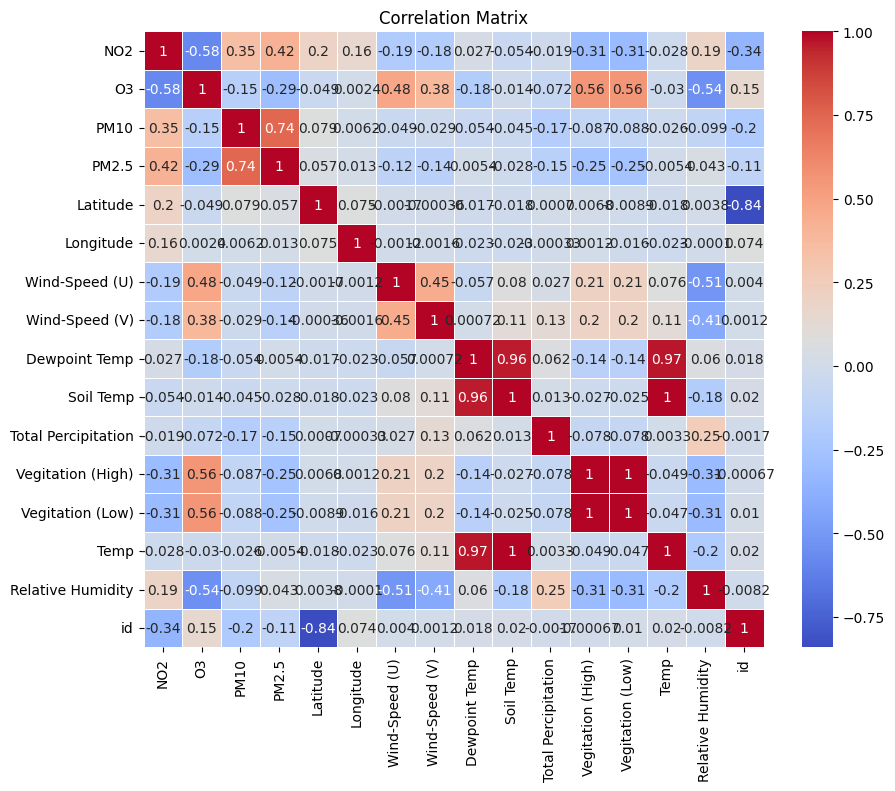

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

**Distribusi Polutan**

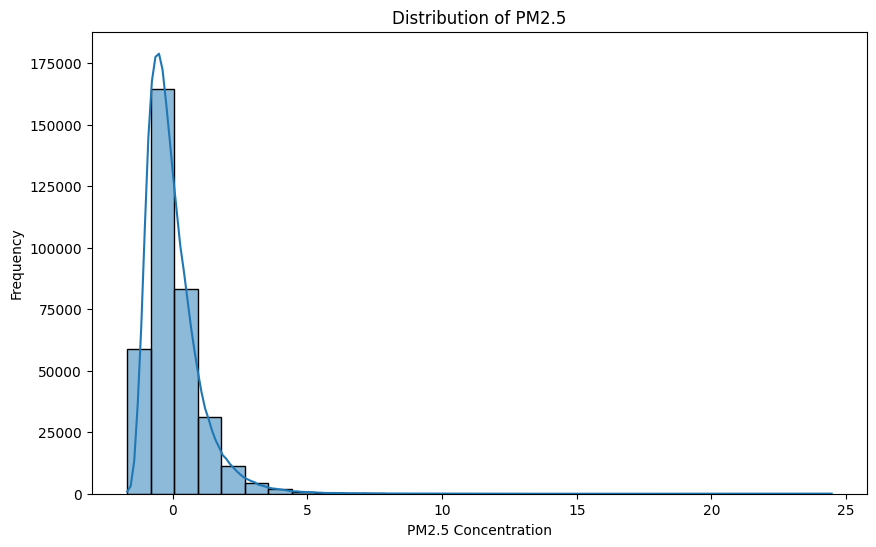

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data['PM2.5'], bins=30, kde=True)
plt.title('Distribution of PM2.5')
plt.xlabel('PM2.5 Concentration')
plt.ylabel('Frequency')
plt.show()

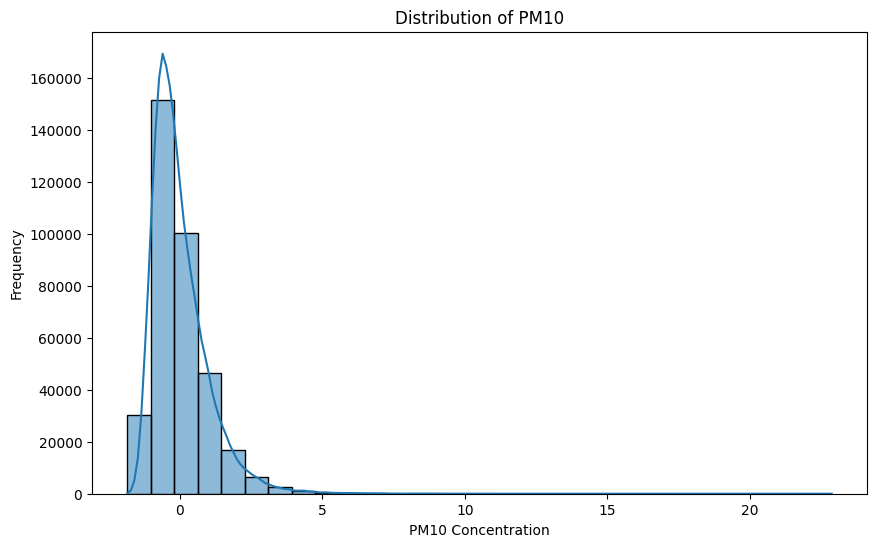

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data['PM10'], bins=30, kde=True)
plt.title('Distribution of PM10')
plt.xlabel('PM10 Concentration')
plt.ylabel('Frequency')
plt.show()

**Polusi Udara Berdasarkan Kota**

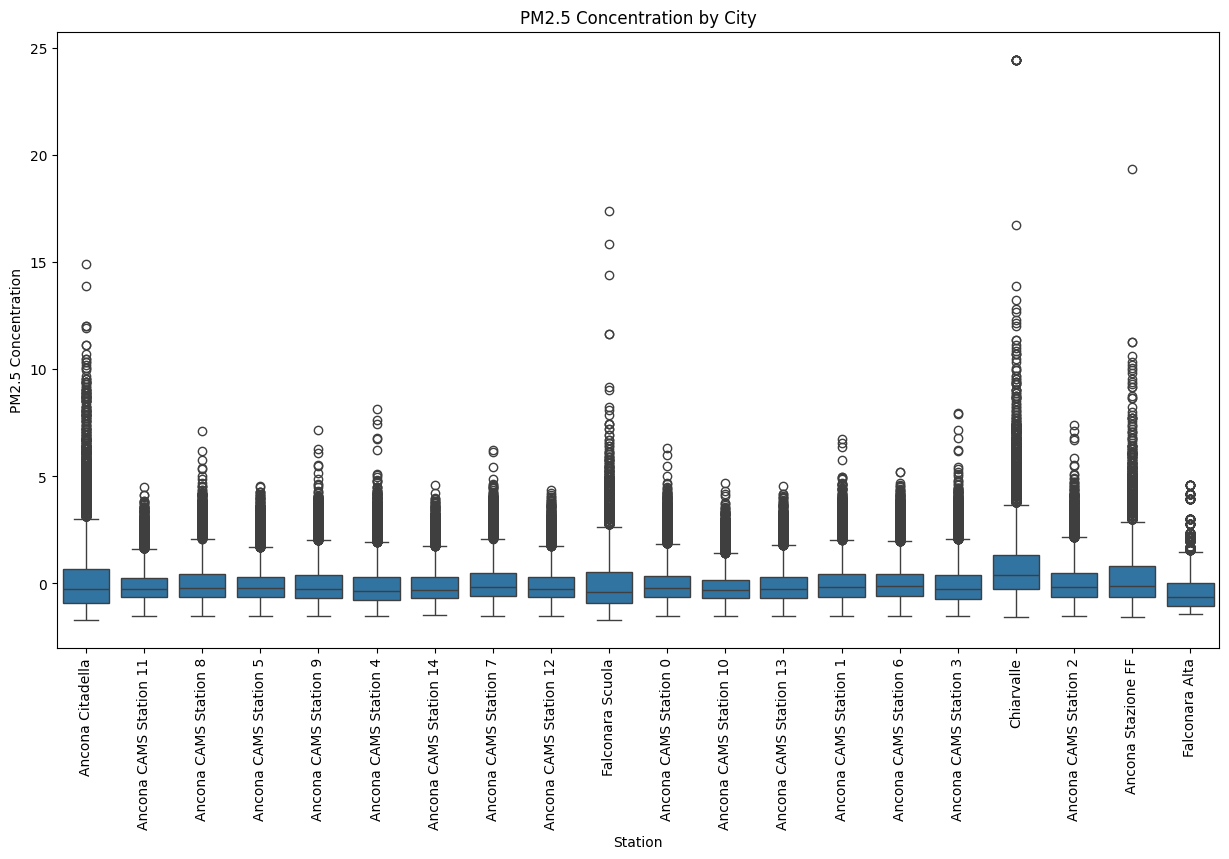

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='station_name', y='PM2.5', data=data)
plt.title('PM2.5 Concentration by City')
plt.xlabel('Station')
plt.ylabel('PM2.5 Concentration')
plt.xticks(rotation=90)
plt.show()

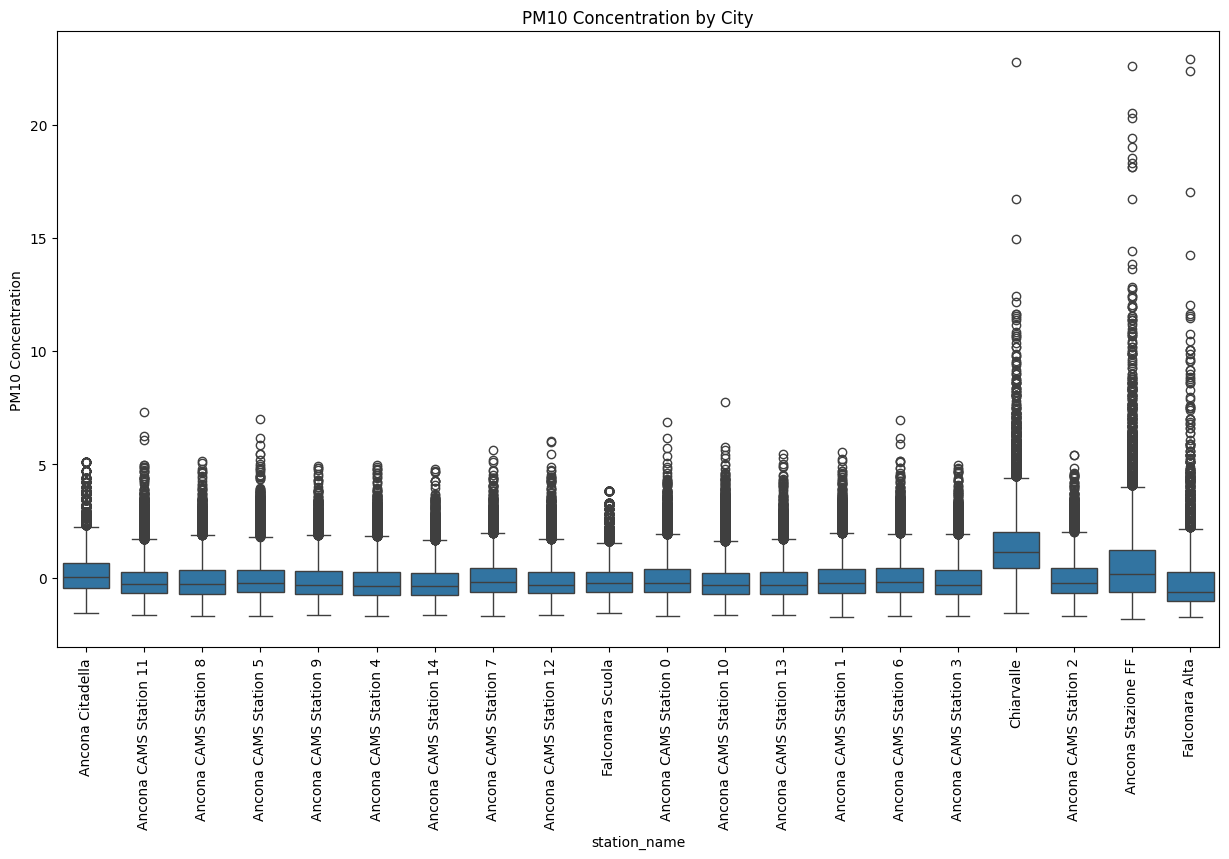

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='station_name', y='PM10', data=data)
plt.title('PM10 Concentration by City')
plt.xlabel('station_name')
plt.ylabel('PM10 Concentration')
plt.xticks(rotation=90)
plt.show()

**Polusi Udara Berdasarkan Waktu**

In [ ]:
data['year'] = data['Date'].dt.year
data['month'] = data['Date'].dt.month

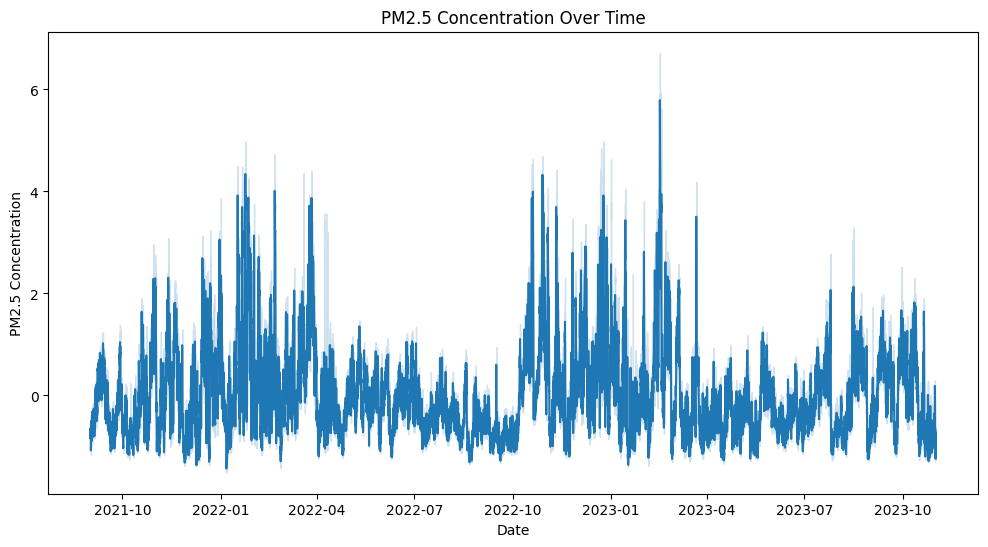

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='PM2.5', data=data)
plt.title('PM2.5 Concentration Over Time')
plt.xlabel('Date')
plt.ylabel('PM2.5 Concentration')
plt.show()

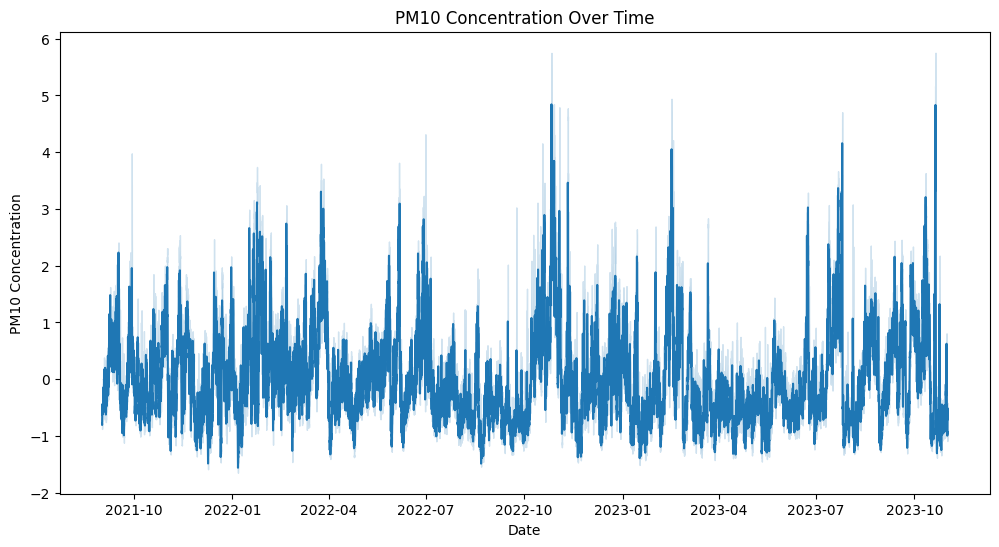

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='PM10', data=data)
plt.title('PM10 Concentration Over Time')
plt.xlabel('Date')
plt.ylabel('PM10 Concentration')
plt.show()

**Deteksi Anomali**

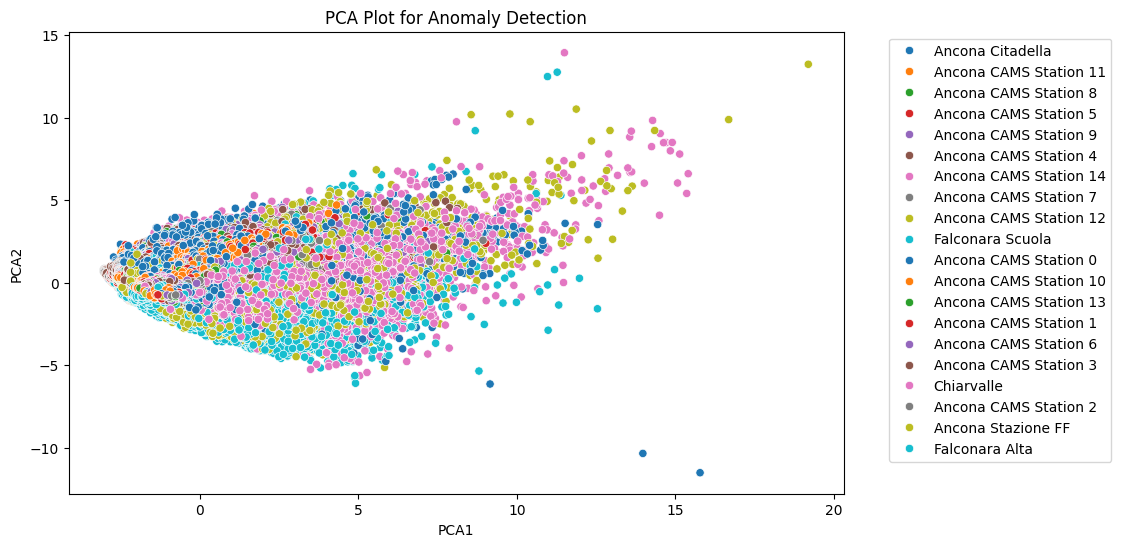

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', data=data, hue='station_name', palette='tab10')
plt.title('PCA Plot for Anomaly Detection')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()